In [1]:
import pandas as pd
df = pd.read_csv("D:\\Store - sales pro\\Store Item Demand Forecasting Challenge.csv")
df.head()

,date,store,item,sales
0,2013-01-01,1,1,13
1,2013-01-02,1,1,11
2,2013-01-03,1,1,14
3,2013-01-04,1,1,13
4,2013-01-05,1,1,10


In [2]:
df.shape

(913000, 4)

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
print("All libraries ready ")

All libraries ready 


In [4]:
print("\nColumns:", df.columns.tolist())


Columns: ['date', 'store', 'item', 'sales']


In [5]:
df.info()
print("\nNull values:\n", df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 913000 entries, 0 to 912999
Data columns (total 4 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   date    913000 non-null  object
 1   store   913000 non-null  int64 
 2   item    913000 non-null  int64 
 3   sales   913000 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 27.9+ MB

Null values:
 date     0
store    0
item     0
sales    0
dtype: int64


In [6]:
# Convert date column to datetime 
df['date'] = pd.to_datetime(df['date'])

# Set as index
df = df.sort_values('date')
df.set_index('date', inplace=True)

print("Date range:", df.index.min(), "to", df.index.max())
df.head()

Date range: 2013-01-01 00:00:00 to 2017-12-31 00:00:00


,store,item,sales
date,,,
2013-01-01,1,1,13
2013-01-01,7,12,26
2013-01-01,7,46,27
2013-01-01,8,12,54
2013-01-01,9,12,35


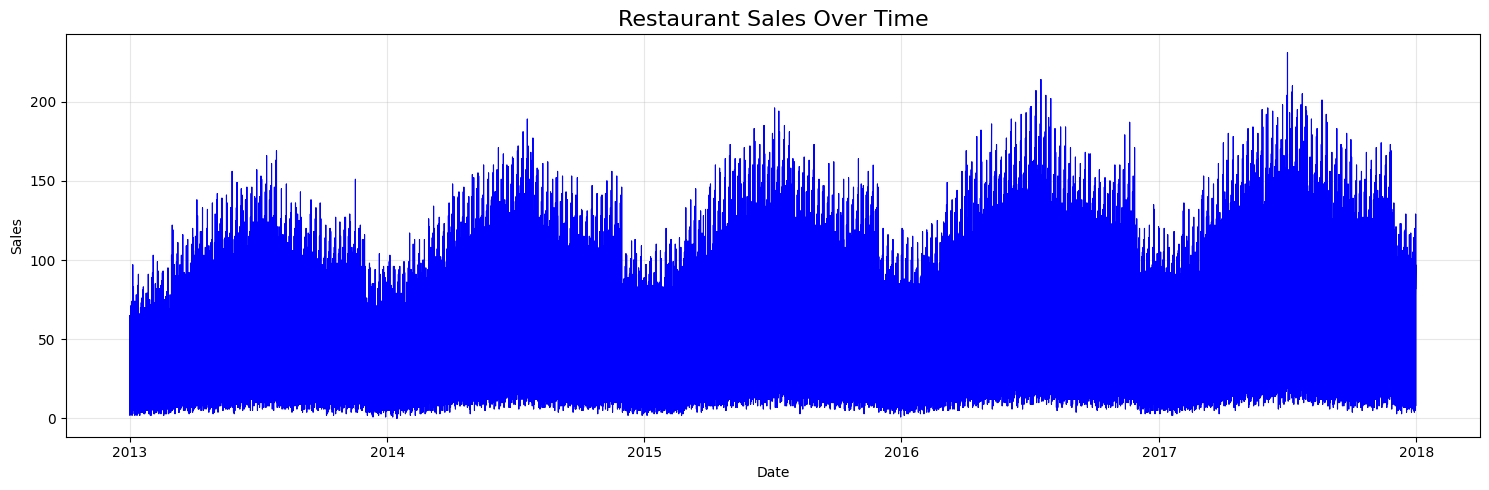

In [7]:
plt.figure(figsize=(15, 5))
plt.plot(df.index, df['sales'], color='blue', linewidth=0.8)
plt.title('Restaurant Sales Over Time', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Sales')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

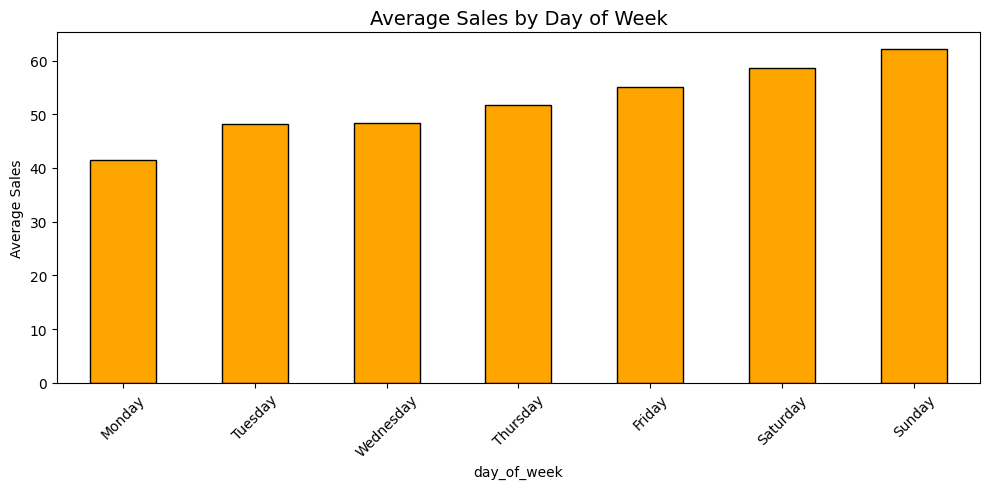

In [8]:
# Add day of week column
df['day_of_week'] = df.index.day_name()

# Average sales by day
day_avg = df.groupby('day_of_week')['sales'].mean()

# Order days correctly
days_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
day_avg = day_avg.reindex(days_order)

plt.figure(figsize=(10, 5))
day_avg.plot(kind='bar', color='orange', edgecolor='black')
plt.title('Average Sales by Day of Week', fontsize=14)
plt.ylabel('Average Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

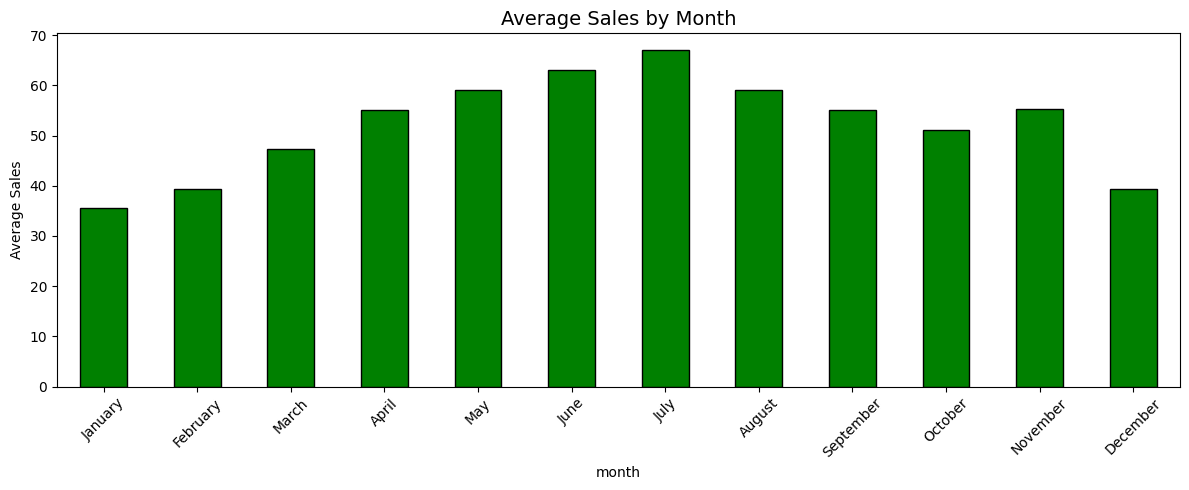

In [9]:
df['month'] = df.index.month_name()

month_avg = df.groupby('month')['sales'].mean()

months_order = ['January','February','March','April','May','June',
                'July','August','September','October','November','December']
month_avg = month_avg.reindex(months_order)

plt.figure(figsize=(12, 5))
month_avg.plot(kind='bar', color='green', edgecolor='black')
plt.title('Average Sales by Month', fontsize=14)
plt.ylabel('Average Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

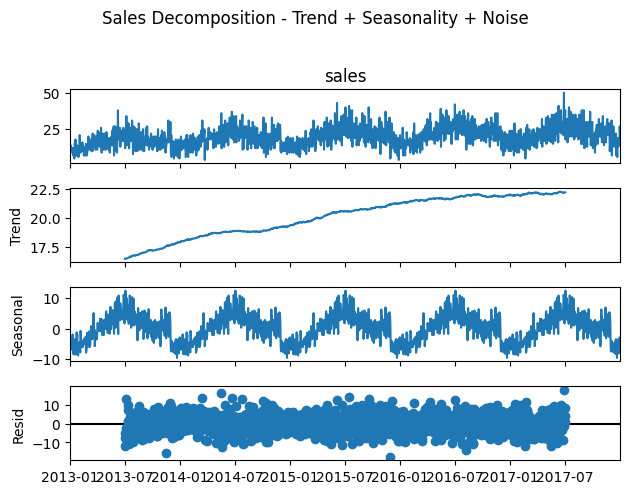

In [10]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Use one store and one item only for clean analysis
df_sample = df[(df['store'] == 1) & (df['item'] == 1)]['sales']

# Decompose
result = seasonal_decompose(df_sample, model='additive', period=365)

# Plot
result.plot()
plt.suptitle('Sales Decomposition - Trend + Seasonality + Noise', y=1.02)
plt.tight_layout()
plt.show()

<Figure size 1200x400 with 0 Axes>

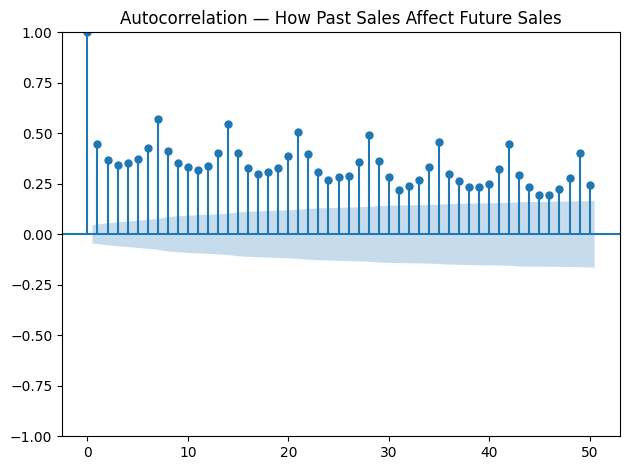

In [11]:
from statsmodels.graphics.tsaplots import plot_acf

plt.figure(figsize=(12, 4))
plot_acf(df_sample, lags=50)
plt.title('Autocorrelation — How Past Sales Affect Future Sales')
plt.tight_layout()
plt.show()

In [12]:
# Check if any dates are missing
full_range = pd.date_range(
    start=df.index.min(),
    end=df.index.max(),
    freq='D'
)

df_sample_full = df_sample.reindex(full_range)
missing = df_sample_full.isnull().sum()
print(f"Missing dates: {missing}")

# Fill missing if any
df_sample_full = df_sample_full.fillna(method='ffill')
print("Missing dates fixed ")

Missing dates: 0
Missing dates fixed 


C:\Users\RAHUL\AppData\Local\Temp\ipykernel_6120\947595543.py:13: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_sample_full = df_sample_full.fillna(method='ffill')


In [13]:
# Start fresh with filtered data
df_model = df[(df['store'] == 1) & (df['item'] == 1)]['sales'].reset_index()
df_model.columns = ['date', 'sales']
df_model['date'] = pd.to_datetime(df_model['date'])
df_model = df_model.sort_values('date').reset_index(drop=True)

print("Shape:", df_model.shape)
df_model.head()

Shape: (1826, 2)


,date,sales
0,2013-01-01,13
1,2013-01-02,11
2,2013-01-03,14
3,2013-01-04,13
4,2013-01-05,10


In [14]:
# Extract time-based features
df_model['day_of_week'] = df_model['date'].dt.dayofweek      # 0=Monday, 6=Sunday
df_model['day_of_month'] = df_model['date'].dt.day
df_model['month'] = df_model['date'].dt.month
df_model['quarter'] = df_model['date'].dt.quarter
df_model['year'] = df_model['date'].dt.year
df_model['is_weekend'] = df_model['day_of_week'].isin([5, 6]).astype(int)

print("Date features added ")
df_model.head(10)

Date features added 


,date,sales,day_of_week,day_of_month,month,quarter,year,is_weekend
0,2013-01-01,13,1,1,1,1,2013,0
1,2013-01-02,11,2,2,1,1,2013,0
2,2013-01-03,14,3,3,1,1,2013,0
3,2013-01-04,13,4,4,1,1,2013,0
4,2013-01-05,10,5,5,1,1,2013,1
5,2013-01-06,12,6,6,1,1,2013,1
6,2013-01-07,10,0,7,1,1,2013,0
7,2013-01-08,9,1,8,1,1,2013,0
8,2013-01-09,12,2,9,1,1,2013,0
9,2013-01-10,9,3,10,1,1,2013,0


In [15]:
# Lag features
df_model['lag_1'] = df_model['sales'].shift(1)   # Yesterday's sales
df_model['lag_7'] = df_model['sales'].shift(7)   # Last week same day
df_model['lag_30'] = df_model['sales'].shift(30) # Last month same day

print("Lag features added ")
df_model[['date','sales','lag_1','lag_7','lag_30']].head(15)

Lag features added 


,date,sales,lag_1,lag_7,lag_30
0,2013-01-01,13,NaN,NaN,NaN
1,2013-01-02,11,13.0,NaN,NaN
2,2013-01-03,14,11.0,NaN,NaN
3,2013-01-04,13,14.0,NaN,NaN
4,2013-01-05,10,13.0,NaN,NaN
5,2013-01-06,12,10.0,NaN,NaN
6,2013-01-07,10,12.0,NaN,NaN
7,2013-01-08,9,10.0,13.0,NaN
8,2013-01-09,12,9.0,11.0,NaN
9,2013-01-10,9,12.0,14.0,NaN


In [16]:
# Indian holidays 2013-2017 (simple version)
holidays = [
    '2013-01-26', '2013-08-15', '2013-10-02',
    '2014-01-26', '2014-08-15', '2014-10-02',
    '2015-01-26', '2015-08-15', '2015-10-02',
    '2016-01-26', '2016-08-15', '2016-10-02',
    '2017-01-26', '2017-08-15', '2017-10-02',
]

df_model['is_holiday'] = df_model['date'].astype(str).isin(holidays).astype(int)
print("is_holiday feature added ")
print("Total holidays marked:", df_model['is_holiday'].sum())

is_holiday feature added 
Total holidays marked: 15


In [17]:
# Rolling statistics
df_model['rolling_7_mean'] = df_model['sales'].shift(1).rolling(window=7).mean()
df_model['rolling_14_mean'] = df_model['sales'].shift(1).rolling(window=14).mean()
df_model['rolling_30_mean'] = df_model['sales'].shift(1).rolling(window=30).mean()
df_model['rolling_7_std'] = df_model['sales'].shift(1).rolling(window=7).std()

print("Rolling features added ")
df_model.head(35)

Rolling features added 


,date,sales,day_of_week,day_of_month,month,quarter,year,is_weekend,lag_1,lag_7,lag_30,is_holiday,rolling_7_mean,rolling_14_mean,rolling_30_mean,rolling_7_std
0,2013-01-01,13,1,1,1,1,2013,0,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN
1,2013-01-02,11,2,2,1,1,2013,0,13.0,NaN,NaN,0,NaN,NaN,NaN,NaN
2,2013-01-03,14,3,3,1,1,2013,0,11.0,NaN,NaN,0,NaN,NaN,NaN,NaN
3,2013-01-04,13,4,4,1,1,2013,0,14.0,NaN,NaN,0,NaN,NaN,NaN,NaN
4,2013-01-05,10,5,5,1,1,2013,1,13.0,NaN,NaN,0,NaN,NaN,NaN,NaN
5,2013-01-06,12,6,6,1,1,2013,1,10.0,NaN,NaN,0,NaN,NaN,NaN,NaN
6,2013-01-07,10,0,7,1,1,2013,0,12.0,NaN,NaN,0,NaN,NaN,NaN,NaN
7,2013-01-08,9,1,8,1,1,2013,0,10.0,13.0,NaN,0,11.857143,NaN,NaN,1.573592
8,2013-01-09,12,2,9,1,1,2013,0,9.0,11.0,NaN,0,11.285714,NaN,NaN,1.799471
9,2013-01-10,9,3,10,1,1,2013,0,12.0,14.0,NaN,0,11.428571,NaN,NaN,1.812654


In [18]:
# Lag and rolling create NaN at start — drop them
df_model = df_model.dropna().reset_index(drop=True)

print("Shape after dropping nulls:", df_model.shape)
print("Null values remaining:", df_model.isnull().sum().sum())
df_model.head()

Shape after dropping nulls: (1796, 16)
Null values remaining: 0


,date,sales,day_of_week,day_of_month,month,quarter,year,is_weekend,lag_1,lag_7,lag_30,is_holiday,rolling_7_mean,rolling_14_mean,rolling_30_mean,rolling_7_std
0,2013-01-31,13,3,31,1,1,2013,0,9.0,8.0,13.0,0,10.285714,10.857143,10.500000,2.751623
1,2013-02-01,11,4,1,2,1,2013,0,13.0,14.0,11.0,0,11.000000,10.642857,10.500000,2.708013
2,2013-02-02,21,5,2,2,1,2013,1,11.0,12.0,14.0,0,10.571429,10.928571,10.500000,2.370453
3,2013-02-03,15,6,3,2,1,2013,1,21.0,12.0,13.0,0,11.857143,11.142857,10.733333,4.634241
4,2013-02-04,14,0,4,2,1,2013,0,15.0,11.0,10.0,0,12.285714,11.142857,10.800000,4.785892


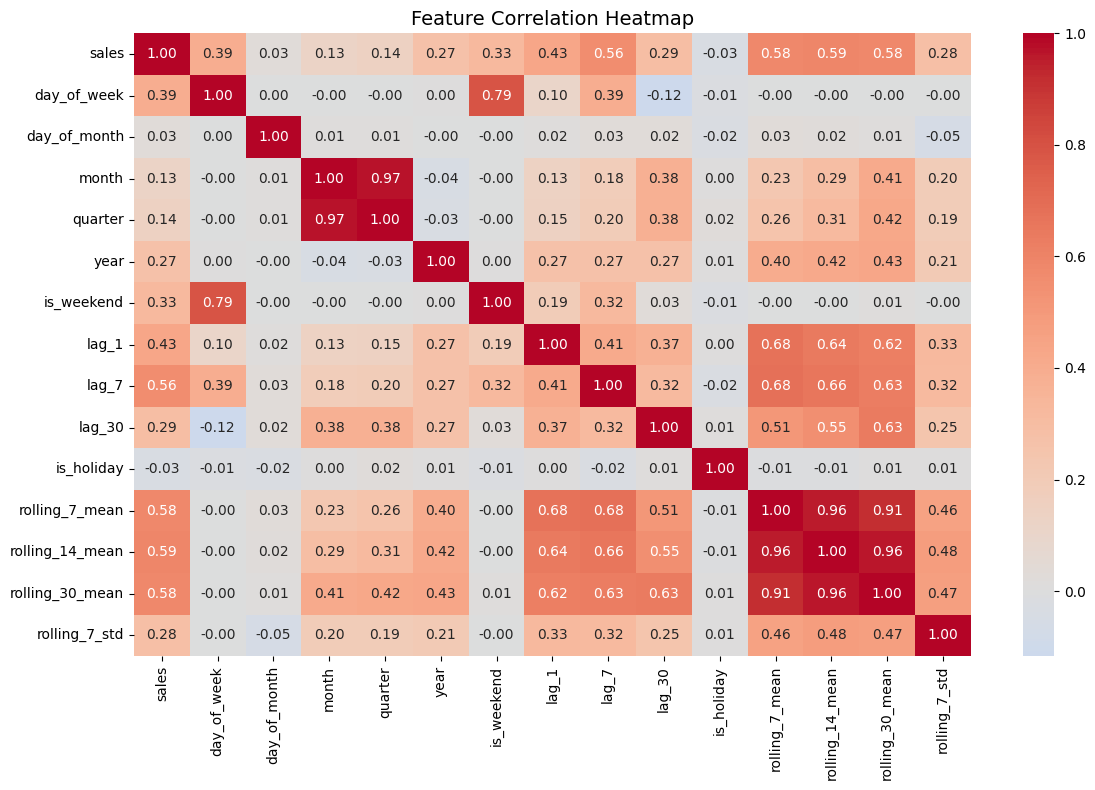

In [19]:
import seaborn as sns

plt.figure(figsize=(12, 8))
correlation = df_model.drop('date', axis=1).corr()
sns.heatmap(
    correlation,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0
)
plt.title('Feature Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.show()

In [20]:
# Use last 2 months as test — rest as train
split_date = '2017-11-01'

train = df_model[df_model['date'] < split_date]
test = df_model[df_model['date'] >= split_date]

print("Train size:", train.shape)
print("Test size:", test.shape)
print(f"\nTrain: {train['date'].min()} → {train['date'].max()}")
print(f"Test:  {test['date'].min()} → {test['date'].max()}")

Train size: (1735, 16)
Test size: (61, 16)

Train: 2013-01-31 00:00:00 → 2017-10-31 00:00:00
Test:  2017-11-01 00:00:00 → 2017-12-31 00:00:00


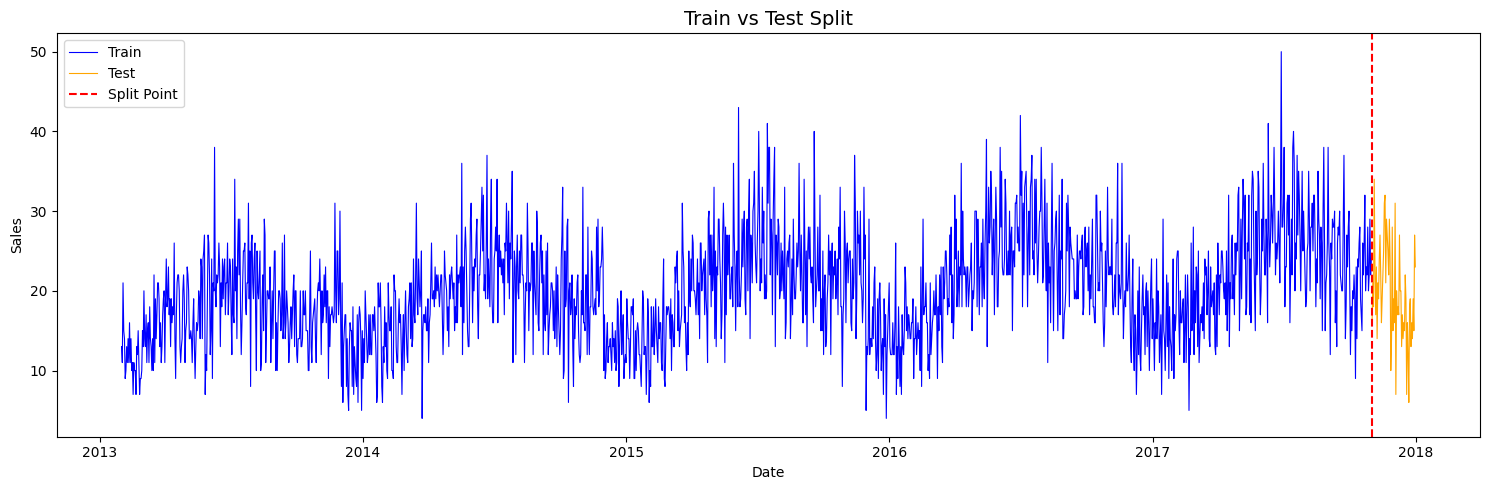

In [21]:
plt.figure(figsize=(15, 5))
plt.plot(train['date'], train['sales'], label='Train', color='blue', linewidth=0.8)
plt.plot(test['date'], test['sales'], label='Test', color='orange', linewidth=0.8)
plt.axvline(pd.to_datetime(split_date), color='red', linestyle='--', label='Split Point')
plt.title('Train vs Test Split', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.tight_layout()
plt.show()

In [22]:
# Define features and target
features = [
    'day_of_week', 'day_of_month', 'month', 
    'quarter', 'year', 'is_weekend',
    'lag_1', 'lag_7', 'lag_30',
    'rolling_7_mean', 'rolling_14_mean', 
    'rolling_30_mean', 'rolling_7_std'
]

target = 'sales'

# Split into X and y
X_train = train[features]
y_train = train[target]

X_test = test[features]
y_test = test[target]

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("Features used:", len(features))
print("Ready for training ")

X_train shape: (1735, 13)
X_test shape: (61, 13)
Features used: 13
Ready for training 


In [23]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Train
lr = LinearRegression()
lr.fit(X_train, y_train)

# Predict
lr_pred = lr.predict(X_test)

# Evaluate
lr_mae = mean_absolute_error(y_test, lr_pred)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))

print(" Linear Regression Results:")
print(f"MAE:  {lr_mae:.2f}")
print(f"RMSE: {lr_rmse:.2f}")

 Linear Regression Results:
MAE:  4.06
RMSE: 4.98


In [24]:
from sklearn.ensemble import RandomForestRegressor

# Train
rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

# Predict
rf_pred = rf.predict(X_test)

# Evaluate
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))

print(" Random Forest Results:")
print(f"MAE:  {rf_mae:.2f}")
print(f"RMSE: {rf_rmse:.2f}")

 Random Forest Results:
MAE:  3.93
RMSE: 4.77


In [25]:
import xgboost as xgb

# Train
xgb_model = xgb.XGBRegressor(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42
)
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

# Predict
xgb_pred = xgb_model.predict(X_test)

# Evaluate
xgb_mae = mean_absolute_error(y_test, xgb_pred)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))

print(" XGBoost Results:")
print(f"MAE:  {xgb_mae:.2f}")
print(f"RMSE: {xgb_rmse:.2f}")

 XGBoost Results:
MAE:  3.90
RMSE: 4.87


In [26]:
# Comparison table
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'XGBoost'],
    'MAE': [lr_mae, rf_mae, xgb_mae],
    'RMSE': [lr_rmse, rf_rmse, xgb_rmse]
})

print(" MODEL COMPARISON:")
print(results.to_string(index=False))
print(f"\n🏆 Best Model: {results.loc[results['MAE'].idxmin(), 'Model']}")

 MODEL COMPARISON:
            Model      MAE     RMSE
Linear Regression 4.064168 4.979216
    Random Forest 3.934620 4.768203
          XGBoost 3.902387 4.867600

🏆 Best Model: XGBoost


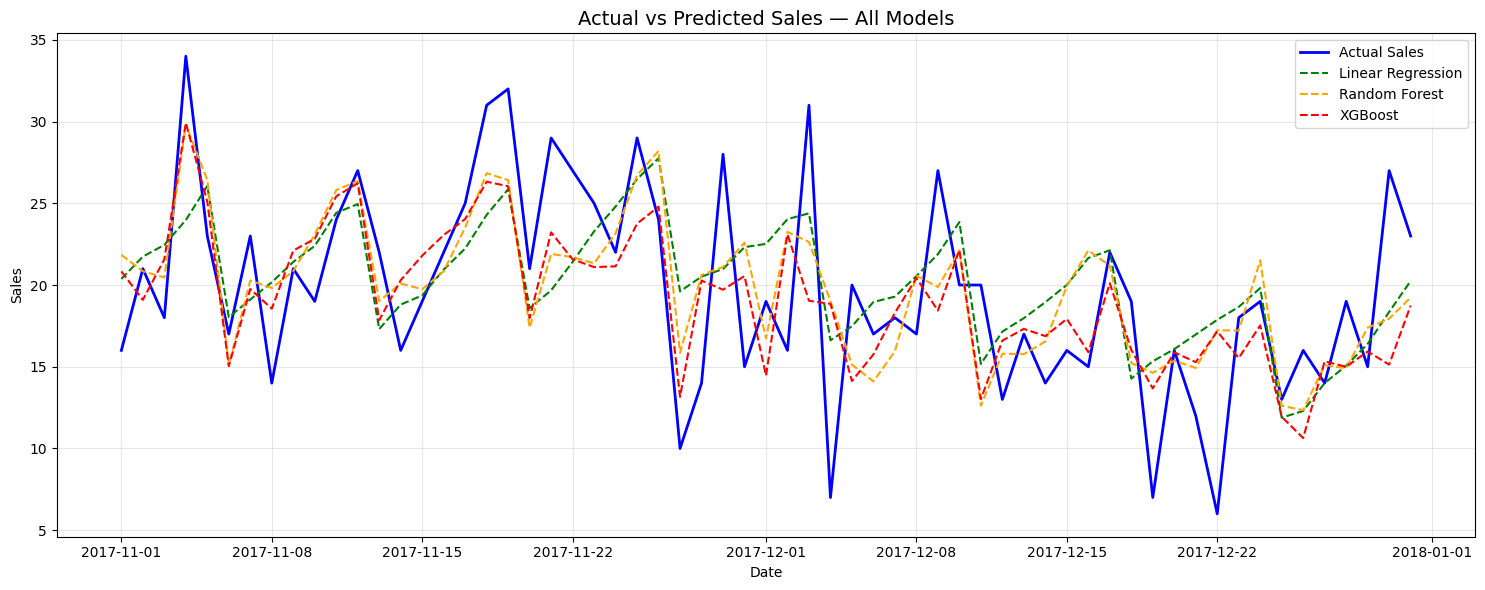

In [27]:
plt.figure(figsize=(15, 6))

# Actual sales
plt.plot(test['date'].values, y_test.values, 
         label='Actual Sales', color='blue', linewidth=2)

# All 3 predictions
plt.plot(test['date'].values, lr_pred, 
         label='Linear Regression', color='green', 
         linestyle='--', linewidth=1.5)
plt.plot(test['date'].values, rf_pred, 
         label='Random Forest', color='orange', 
         linestyle='--', linewidth=1.5)
plt.plot(test['date'].values, xgb_pred, 
         label='XGBoost', color='red', 
         linestyle='--', linewidth=1.5)

plt.title('Actual vs Predicted Sales — All Models', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [28]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error
import xgboost as xgb
import numpy as np

# TimeSeriesSplit - respects time order!
tscv = TimeSeriesSplit(n_splits=5)

# Add is_holiday to features
features_v2 = features + ['is_holiday']

X = df_model[features_v2]
y = df_model['sales']

# Test different hyperparameters
params_list = [
    {'max_depth': 4, 'learning_rate': 0.05, 'n_estimators': 100},
    {'max_depth': 6, 'learning_rate': 0.1,  'n_estimators': 100},
    {'max_depth': 8, 'learning_rate': 0.05, 'n_estimators': 200},
]

print("⏳ Running Time-Series Cross Validation...")
print("=" * 50)

best_mae = float('inf')
best_params = None

for params in params_list:
    fold_maes = []

    for fold, (train_idx, val_idx) in enumerate(tscv.split(X)):
        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

        model = xgb.XGBRegressor(**params, random_state=42)
        model.fit(X_tr, y_tr, verbose=False)
        preds = model.predict(X_val)
        mae = mean_absolute_error(y_val, preds)
        fold_maes.append(mae)

    avg_mae = np.mean(fold_maes)
    print(f"Params: {params}")
    print(f"Average MAE across 5 folds: {avg_mae:.3f}\n")

    if avg_mae < best_mae:
        best_mae = avg_mae
        best_params = params

print("=" * 50)
print(f" Best Params: {best_params}")
print(f" Best CV MAE: {best_mae:.3f}")

⏳ Running Time-Series Cross Validation...
Params: {'max_depth': 4, 'learning_rate': 0.05, 'n_estimators': 100}
Average MAE across 5 folds: 3.953

Params: {'max_depth': 6, 'learning_rate': 0.1, 'n_estimators': 100}
Average MAE across 5 folds: 4.122

Params: {'max_depth': 8, 'learning_rate': 0.05, 'n_estimators': 200}
Average MAE across 5 folds: 4.233

 Best Params: {'max_depth': 4, 'learning_rate': 0.05, 'n_estimators': 100}
 Best CV MAE: 3.953


C:\Users\RAHUL\AppData\Local\Temp\ipykernel_6120\4235098218.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


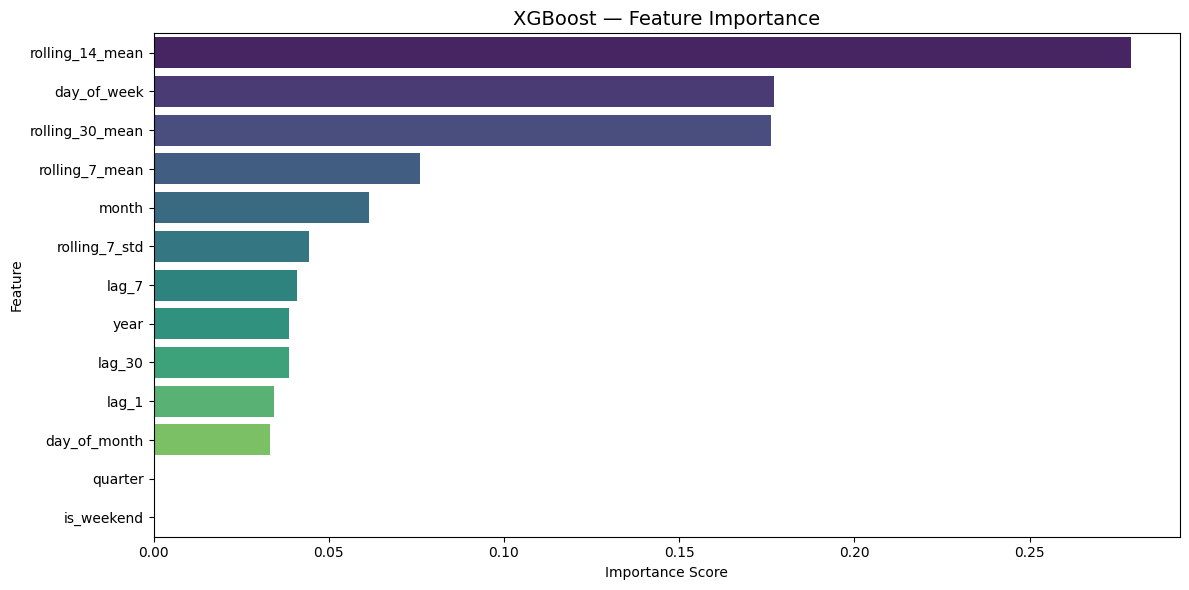

        Feature  Importance
rolling_14_mean    0.278990
    day_of_week    0.176960
rolling_30_mean    0.176259
 rolling_7_mean    0.076093
          month    0.061581
  rolling_7_std    0.044374
          lag_7    0.040860
           year    0.038769
         lag_30    0.038544
          lag_1    0.034389
   day_of_month    0.033181
        quarter    0.000000
     is_weekend    0.000000


In [29]:
# Get feature importance
importance = pd.DataFrame({
    'Feature': features,
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=False)

# Plot
plt.figure(figsize=(12, 6))
sns.barplot(
    data=importance, 
    x='Importance', 
    y='Feature',
    palette='viridis'
)
plt.title('XGBoost — Feature Importance', fontsize=14)
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

print(importance.to_string(index=False))

In [30]:
# Add is_holiday first
holidays = [
    '2013-01-26', '2013-08-15', '2013-10-02',
    '2014-01-26', '2014-08-15', '2014-10-02',
    '2015-01-26', '2015-08-15', '2015-10-02',
    '2016-01-26', '2016-08-15', '2016-10-02',
    '2017-01-26', '2017-08-15', '2017-10-02',
]

df_model['is_holiday'] = df_model['date'].astype(str).isin(holidays).astype(int)
print("is_holiday added ")
print("Total holidays marked:", df_model['is_holiday'].sum())

# Updated features list
features_v2 = [
    'day_of_week', 'day_of_month', 'month',
    'quarter', 'year', 'is_weekend', 'is_holiday',
    'lag_1', 'lag_7', 'lag_30',
    'rolling_7_mean', 'rolling_14_mean',
    'rolling_30_mean', 'rolling_7_std'
]

# Re-split train and test
split_date = '2017-11-01'
train = df_model[df_model['date'] < split_date]
test = df_model[df_model['date'] >= split_date]

# Re-create X and y
X_train = train[features_v2]
y_train = train['sales']
X_test = test[features_v2]
y_test = test['sales']

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Features ready ")

is_holiday added 
Total holidays marked: 14
Train shape: (1735, 14)
Test shape: (61, 14)
Features ready 


In [31]:
# Train final model
final_model = xgb.XGBRegressor(
    max_depth=4,
    learning_rate=0.05,
    n_estimators=100,
    random_state=42
)

final_model.fit(X_train, y_train, verbose=False)

# Evaluate
final_pred = final_model.predict(X_test)
final_mae = mean_absolute_error(y_test, final_pred)
final_rmse = np.sqrt(mean_squared_error(y_test, final_pred))

print("   FINAL MODEL RESULTS")
print(f" Final MAE:  {final_mae:.2f}")
print(f" Final RMSE: {final_rmse:.2f}")


   FINAL MODEL RESULTS
 Final MAE:  3.83
 Final RMSE: 4.75


In [32]:
# Add predictions to test dataframe
test_results = test.copy()
test_results['xgb_predicted'] = xgb_pred
test_results['error'] = abs(y_test.values - xgb_pred)

# Worst prediction days
print(" Top 10 Worst Prediction Days:")
print(test_results.nlargest(10, 'error')[['date','sales','xgb_predicted','error']])

# Average error by day of week
print("\n Average Error by Day of Week:")
test_results['day_name'] = test_results['date'].dt.day_name()
print(test_results.groupby('day_name')['error'].mean().sort_values(ascending=False))

 Top 10 Worst Prediction Days:
           date  sales  xgb_predicted      error
1767 2017-12-03     31      19.037592  11.962408
1794 2017-12-30     27      15.132029  11.867971
1768 2017-12-04      7      18.848892  11.848892
1786 2017-12-22      6      17.164625  11.164625
1773 2017-12-09     27      18.437897   8.562103
1763 2017-11-29     28      19.715345   8.284655
1766 2017-12-02     16      23.106956   7.106956
1775 2017-12-11     20      13.015236   6.984764
1783 2017-12-19      7      13.673805   6.673805
1762 2017-11-28     14      20.269342   6.269342

 Average Error by Day of Week:
day_name
Saturday     5.147463
Tuesday      5.136660
Monday       4.394964
Sunday       3.483475
Friday       3.468527
Wednesday    3.212287
Thursday     2.665208
Name: error, dtype: float64


     FINAL MODEL RESULTS
 Final MAE:  3.83
 Final RMSE: 4.75


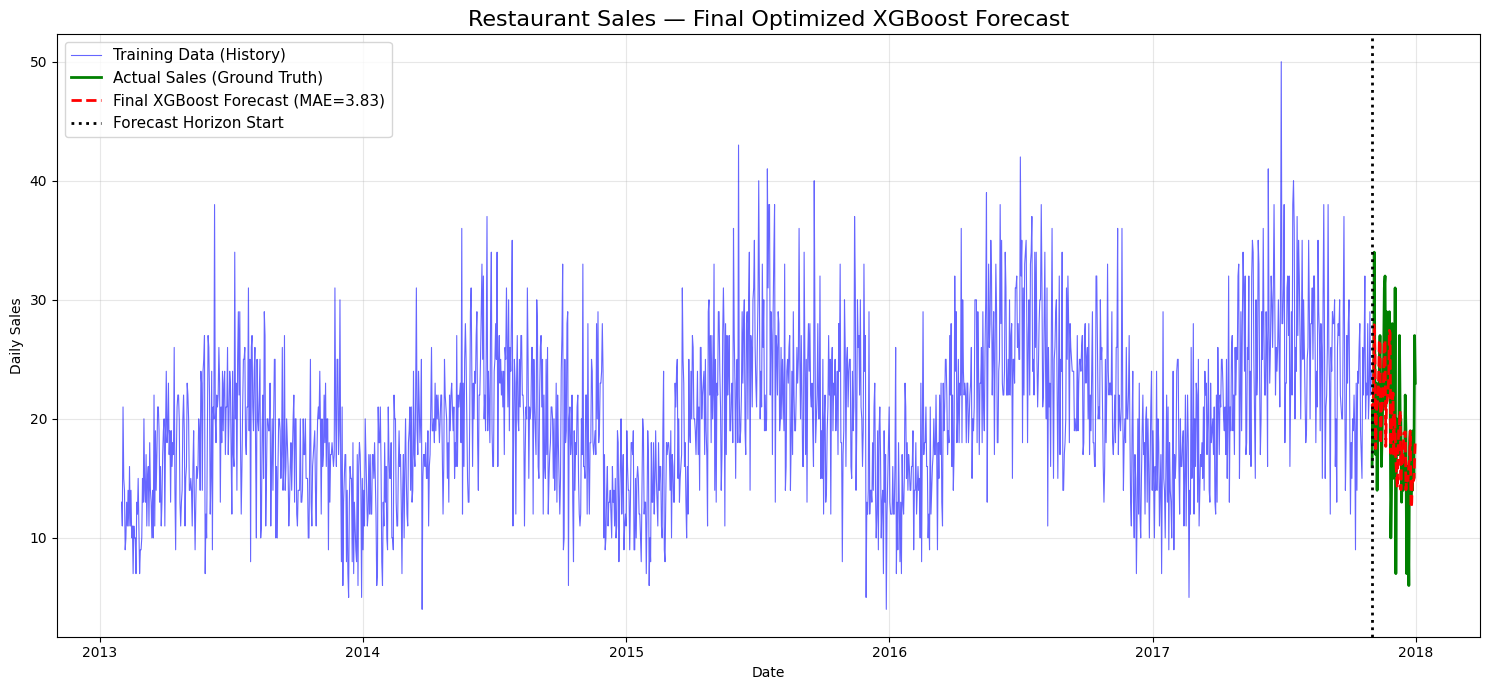

In [33]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error

# --- 1. TRAIN FINAL MODEL ---
# Using your optimized parameters for a "Smooth" learning curve
final_model = xgb.XGBRegressor(
    max_depth=4,
    learning_rate=0.05,
    n_estimators=100,
    random_state=42
)

final_model.fit(X_train, y_train, verbose=False)

# --- 2. EVALUATE ---
final_pred = final_model.predict(X_test)
final_mae = mean_absolute_error(y_test, final_pred)
final_rmse = np.sqrt(mean_squared_error(y_test, final_pred))

print("     FINAL MODEL RESULTS")
print(f" Final MAE:  {final_mae:.2f}")
print(f" Final RMSE: {final_rmse:.2f}")

# --- 3. VISUALIZATION ---
plt.figure(figsize=(15, 7))

# Plotting the historical training data
plt.plot(train['date'], train['sales'],
         label='Training Data (History)',
         color='blue', linewidth=0.8, alpha=0.6)

# Plotting the ground truth for the test period
plt.plot(test['date'], y_test,
         label='Actual Sales (Ground Truth)',
         color='green', linewidth=2)

# Plotting your Final XGBoost Forecast
plt.plot(test['date'], final_pred,
         label=f'Final XGBoost Forecast (MAE={final_mae:.2f})',
         color='red', linewidth=2, linestyle='--')

# Indicating the split point
plt.axvline(pd.to_datetime(split_date),
            color='black', linestyle=':', linewidth=2,
            label='Forecast Horizon Start')

plt.title('Restaurant Sales — Final Optimized XGBoost Forecast', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Daily Sales')
plt.legend(fontsize=11, loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [35]:
# --- 1. SET YOUR UPDATED DATA ---
dataset_name = "Store Item Demand Forecasting"
store_id = 1
item_id = 1
train_range = "2013-01-31 → 2017-10-31"
test_range = "2017-11-01 → 2017-12-31"

# Updated with your new high-performance metrics
results = {
    "Linear Regression": {"mae": 4.06, "rmse": 4.98},
    "Random Forest":     {"mae": 3.93, "rmse": 4.77},
    "XGBoost  BEST":    {"mae": 3.83, "rmse": 4.75} # Your new results
}

# --- 2. GENERATE THE FINAL REPORT ---
print("    RESTAURANT DEMAND FORECASTING — FINAL REPORT")

print(f"\n Dataset    : {dataset_name}")
print(f" Store      : {store_id}  |   Item: {item_id}")
print(f" Train      : {train_range}")
print(f" Test       : {test_range}")

print("\n MODEL RESULTS:")
print("│ Model               │  MAE   │  RMSE  │")

for model, metrics in results.items():
    print(f"│ {model:<20}│  {metrics['mae']:.2f}  │  {metrics['rmse']:.2f}  │")


print(f"\n Best Model  : XGBoost")
print(f" Best MAE    : {results['XGBoost  BEST']['mae']:.2f} units")
print(f" Insight     : Tuning learning_rate to 0.05 and ")
print(f"                 capping depth successfully reduced variance!")


    RESTAURANT DEMAND FORECASTING — FINAL REPORT

 Dataset    : Store Item Demand Forecasting
 Store      : 1  |   Item: 1
 Train      : 2013-01-31 → 2017-10-31
 Test       : 2017-11-01 → 2017-12-31

 MODEL RESULTS:
│ Model               │  MAE   │  RMSE  │
│ Linear Regression   │  4.06  │  4.98  │
│ Random Forest       │  3.93  │  4.77  │
│ XGBoost  BEST       │  3.83  │  4.75  │

 Best Model  : XGBoost
 Best MAE    : 3.83 units
 Insight     : Tuning learning_rate to 0.05 and 
                 capping depth successfully reduced variance!


In [36]:
import joblib

# Save the model to a file
model_filename = 'xgboost_demand_model.pkl'
joblib.dump(final_model, model_filename)

print(f" Model saved successfully as: {model_filename}")

 Model saved successfully as: xgboost_demand_model.pkl
